In [34]:
import numpy as np
import uproot
import matplotlib.pyplot as plt

In [35]:
file = uproot.open("histograms_Run00001.root")
file.keys()

['param_dir;1',
 'param_dir/A;1',
 'param_dir/GEANT4isotopes;1',
 'param_dir/GEM1_HV;1',
 'param_dir/GEM2_HV;1',
 'param_dir/GEM3_HV;1',
 'param_dir/NR;1',
 'param_dir/Parallel_threads;1',
 'param_dir/SRIM;1',
 'param_dir/Vignetting;1',
 'param_dir/WID;1',
 'param_dir/absorption_l;1',
 'param_dir/bckg;1',
 'param_dir/beta;1',
 'param_dir/camera_aperture;1',
 'param_dir/diff_coeff_L;1',
 'param_dir/diff_coeff_T;1',
 'param_dir/diff_const_sigma0L;1',
 'param_dir/diff_const_sigma0T;1',
 'param_dir/donotremove;1',
 'param_dir/events;1',
 'param_dir/exposure_time;1',
 'param_dir/exposure_time_effect;1',
 'param_dir/fixed_seed;1',
 'param_dir/ion_pot;1',
 'param_dir/photons_per_el;1',
 'param_dir/queue;1',
 'param_dir/randZ_range;1',
 'param_dir/random_ped;1',
 'param_dir/redpix_output;1',
 'param_dir/rootfiles;1',
 'param_dir/saturation;1',
 'param_dir/start_event;1',
 'param_dir/start_run_number;1',
 'param_dir/x_dim;1',
 'param_dir/x_extra;1',
 'param_dir/x_offset;1',
 'param_dir/xy_vox_s

In [36]:
tree = file["event_info"]
print(tree.keys())

['eventnumber', 'particle_type', 'energy', 'theta', 'phi', 'track_length_3D', 'proj_track_2D', 'x_vertex', 'y_vertex', 'z_vertex', 'x_vertex_end', 'y_vertex_end', 'z_vertex_end', 'x_min', 'x_max', 'y_min', 'y_max', 'z_min', 'z_max', 'N_photons', 'px', 'py', 'pz', 'nhits_og', 'nRedpix', 'redpix_ix', 'redpix_iy', 'redpix_iz']


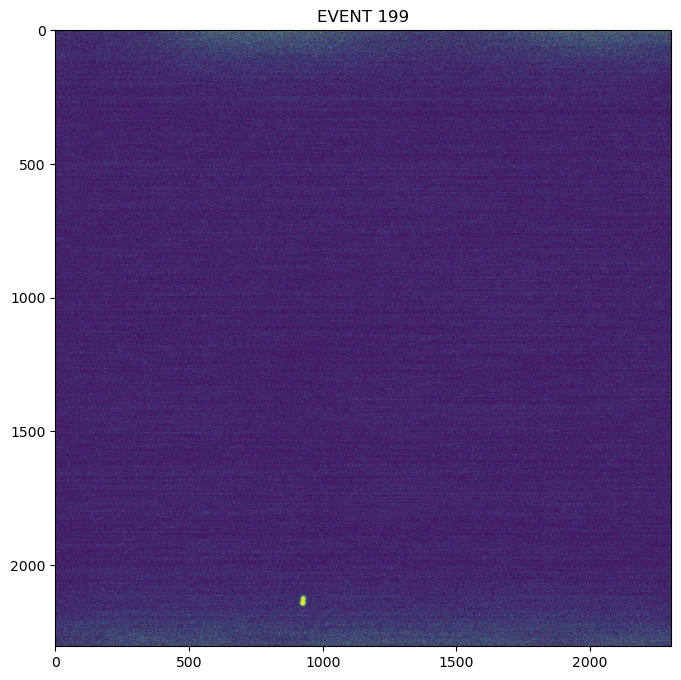

In [37]:
i = 199
image = file["pic_run1_ev{:d}".format(i)].to_numpy()
fig =plt.figure(figsize = (8,8))
plt.title("EVENT {:d}".format(i))
plt.imshow(image[0].T, vmin = 99, vmax = 120)
plt.show()

In [38]:
# How to extract redpixes (example)

ixs = tree["redpix_ix"].arrays(library="np")["redpix_ix"]
iys = tree["redpix_iy"].arrays(library="np")["redpix_iy"]
izs = tree["redpix_iz"].arrays(library="np")["redpix_iz"]

In [39]:
# Choose the same image/event
ievent = i
ix_event = ixs[ievent]
iy_event = iys[ievent]
iz_event = izs[ievent]

In [40]:
# Determine image shape (optional: you may already know it)
max_x = 2304 #4096 for QUEST digitization
max_y = 2304

# Create and fill image
image = np.zeros((max_x, max_y), dtype=np.uint16)
image[ix_event, iy_event] = iz_event  # assumes no duplicates

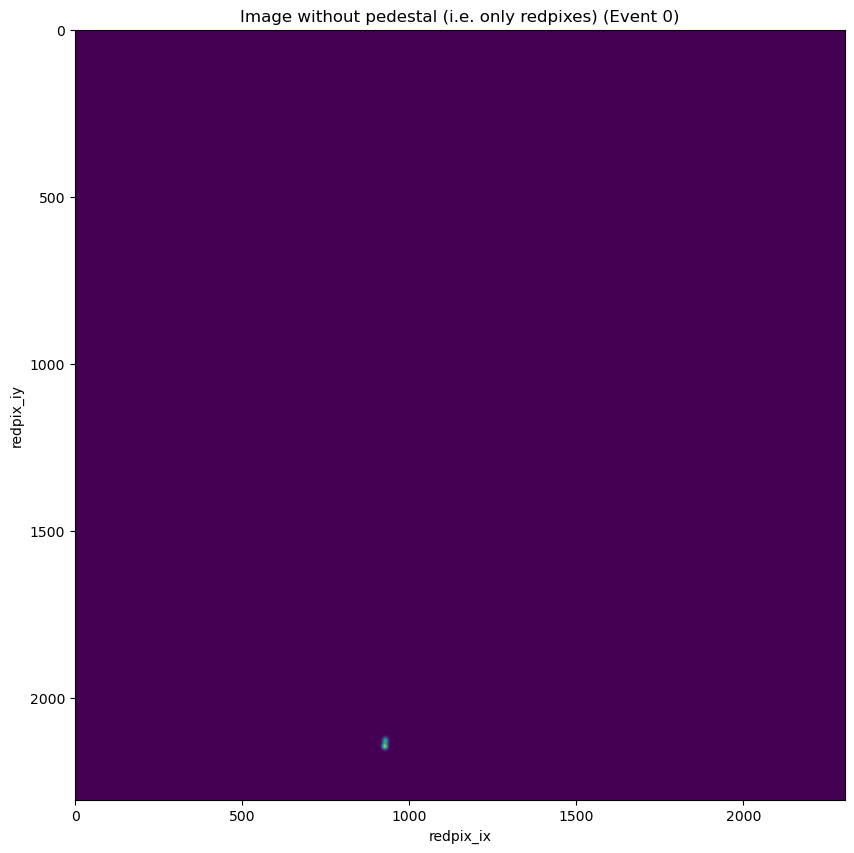

In [41]:
# Display image
plt.figure(figsize=(10,10))
plt.imshow(image.T, origin='lower', cmap='viridis')
#plt.colorbar(label='redpix_iz')
plt.xlabel('redpix_ix')
plt.ylabel('redpix_iy')
# Flip y axis from max to 0
plt.gca().invert_yaxis()
plt.title('Image without pedestal (i.e. only redpixes) (Event 0)')
#plt.savefig("./redpix.pdf")
plt.show()